# Part 10: Real-World Constraints on Best Strategy

The top-performing strategy in our backtest, measured by final bankroll, is the RBF + Ridge (Selective, Half-Kelly w. 10% cap, t>6) model, which executed just 30 bets. As demonstrated in Part 8, these positive returns are statistically insignificant despite the simulated bankroll finishing in profit. Below, we outline why this strategy is ultimately unviable for deployment in any realistic, scaled portfolio.

In [21]:
# ======================================================================
# Part 10: Real-World Constraints and Strategy Selection
# ======================================================================

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import erf, sqrt

# ── Load caches ──
with open('Data/model_training_cache.pkl', 'rb') as f:
    part8_cache = pickle.load(f)

# ── Load Part 8 test set ──
part8_test_df = pd.read_csv('Data/part8_test_df.csv')
part8_test_df['date'] = pd.to_datetime(part8_test_df['date'])

# ── Extract Part 8 predictions ──
preds_tuned = part8_cache['preds_tuned']
p8_rbf_pred = np.array(preds_tuned['RBF+Ridge'])

# Common arrays
actual  = part8_test_df['actual_total'].values
vegas   = part8_test_df['vegas_total'].values
dates   = part8_test_df['date'].values
n_games = len(actual)

# ── Constants ──
ODDS       = -110
LOSE       = abs(ODDS) / 100
BREAK_EVEN = LOSE / (LOSE + 1.0)
START_BANK = 10_000.0
THRESHOLD  = 6
LABEL      = 'RBF+Ridge (selective, t>6)'


def flat_metrics(pred, actual, vegas, label, threshold=0):
    gap  = np.abs(pred - vegas)
    mask = gap > threshold if threshold > 0 else np.ones(len(pred), dtype=bool)
    p, a, v = pred[mask], actual[mask], vegas[mask]
    correct = np.where(p > v, a > v, a < v)
    pushes  = a == v
    wins    = correct & ~pushes
    losses  = ~correct & ~pushes
    n   = len(p)
    acc = wins.sum() / (wins.sum() + losses.sum()) if (wins.sum() + losses.sum()) > 0 else 0
    roi = (wins.sum() - losses.sum() * LOSE) / n * 100 if n > 0 else 0
    return {'strategy': label, 'bets': n, 'accuracy': acc, 'roi_pct': roi}


# ======================================================================
# 10.1 — Why ROI Alone Is Insufficient
# ======================================================================

print("\n" + "=" * 70)
print("10.1 — STRATEGY CANDIDATE: RBF+Ridge at gap > 6")
print("=" * 70)

m = flat_metrics(p8_rbf_pred, actual, vegas, LABEL, threshold=THRESHOLD)
print(f"  Bets: {m['bets']} | Accuracy: {m['accuracy']:.1%} | "
      f"Flat ROI: {m['roi_pct']:+.2f}% | Acc vs BE: {(m['accuracy'] - BREAK_EVEN)*100:+.1f}pp")
print(f"  Break-even at {ODDS} odds: {BREAK_EVEN:.1%}")
print(f"\n  This is the only strategy from Parts 8 or 9 that produces a positive")
print(f"  bankroll under Kelly sizing. But +9% ROI on 30 bets could easily be luck.")
print(f"  Part 10 stress-tests whether this edge survives real-world frictions.")



10.1 — STRATEGY CANDIDATE: RBF+Ridge at gap > 6
  Bets: 30 | Accuracy: 56.7% | Flat ROI: +9.00% | Acc vs BE: +4.3pp
  Break-even at -110 odds: 52.4%

  This is the only strategy from Parts 8 or 9 that produces a positive
  bankroll under Kelly sizing. But +9% ROI on 30 bets could easily be luck.
  Part 10 stress-tests whether this edge survives real-world frictions.


## 10.2 - Bankroll Simulation and Metrics

The Half-Kelly simulation produces a positive ending bankroll of $11,111 (+11.1%) on 30 bets, but the path to get there is rough. The strategy hits a maximum drawdown of -31.7%, meaning at its worst point, the bankroll dropped nearly a third from its peak. For context, a -32% drawdown to earn +11% is a drawdown-to-return ratio of roughly 3:1, well outside what any institutional allocator would accept. 


The average stake fraction is 10.0%, the maximum allowed cap, indicating the Kelly model is highly confident on every bet it places, there is no granularity in sizing, just full-conviction or nothing. This makes the bankroll path binary and volatile, reflected in the $1,147 per-bet PnL standard deviation (roughly 11% of the starting bankroll swinging on each bet).

The bankroll position analysis tells a more nuanced story. The median position is +5.4% above start, and the strategy spends only 27% of its bets underwater, so it is above water most of the time. But the range spans from -9.1% to +33.1%, meaning the bankroll swings by over 40 percentage points across just 30 bets. The positive ending is partially a product of sequencing: a cluster of wins near the peak inflates the bankroll before later losses bring it back down.



10.2 — BANKROLL SIMULATION (Half-Kelly, cap 10%)

Half-Kelly Bankroll Simulation ($10,000 start, gap > 6)
──────────────────────────────────────────────────────────────────────
  Bets placed:           30
  Ending bankroll:       $11,111 (+11.1%)
  Max drawdown:          -31.7%
  Avg stake fraction:    10.0%
  Per-bet PnL std dev:   $1,147

  ── Bankroll Position After Each Bet (% from $10,000) ──
  Median:                +5.4%
  Min:                   -9.1%
  Max:                   +33.1%
  Time spent underwater: 27% of bets


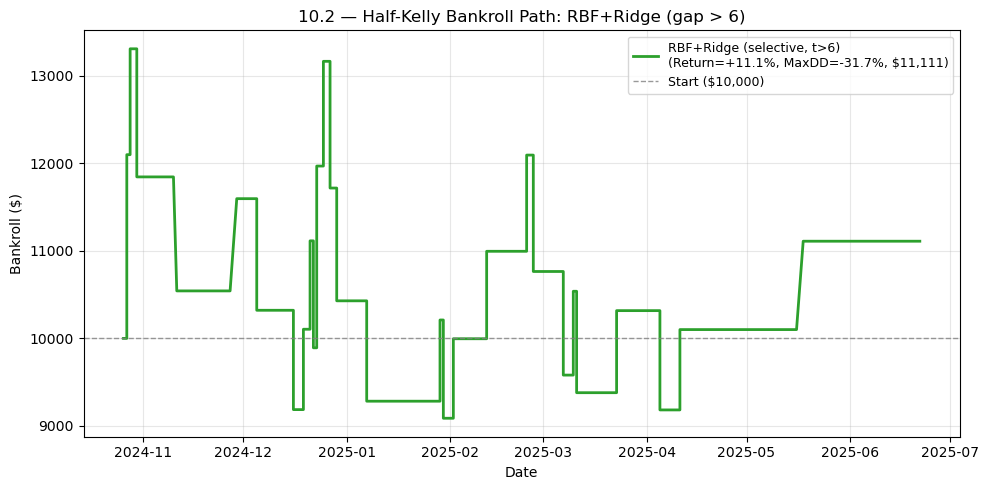

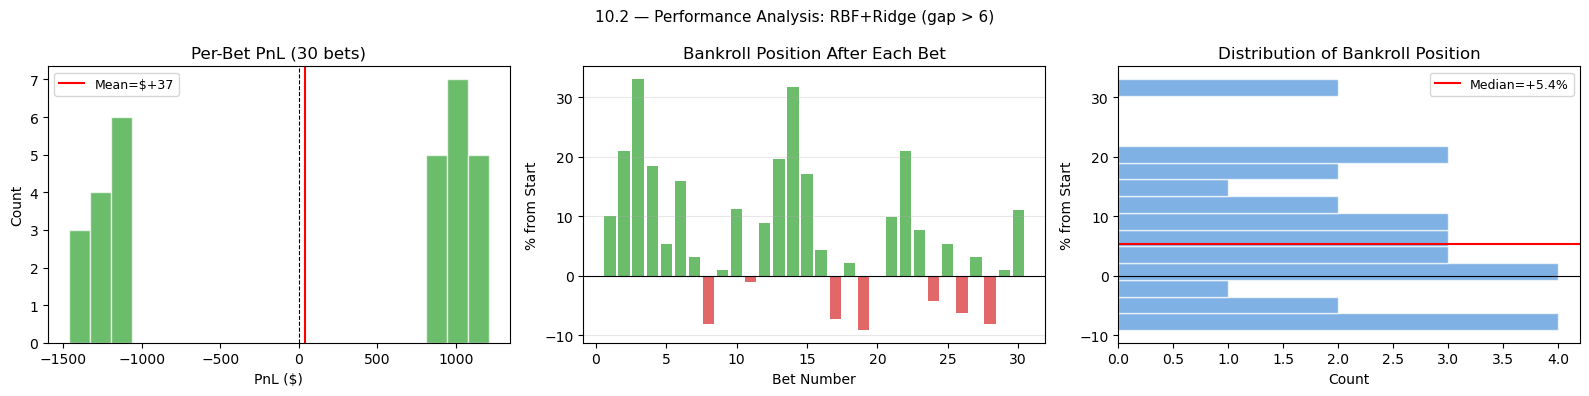

In [22]:
# ======================================================================
# 10.2 — Bankroll Simulation
# ======================================================================

print("\n" + "=" * 70)
print("10.2 — BANKROLL SIMULATION (Half-Kelly, cap 10%)")
print("=" * 70)

normal_cdf_vec = np.vectorize(lambda x: 0.5 * (1.0 + erf(x / sqrt(2.0))))


def simulate_kelly(dates, pred, actual, vegas, threshold=0,
                   start_bankroll=START_BANK, odds=ODDS, execution_vegas=None):
    """
    Simulates Kelly bankroll.
    `vegas` is the line used for the signal (gap threshold + Kelly sizing).
    `execution_vegas` is the line the bet is filled at (for slippage testing).
    """
    lose_amt = abs(odds) / 100
    b        = 1.0 / lose_amt

    pred   = np.asarray(pred, dtype=float)
    actual = np.asarray(actual, dtype=float)
    vegas  = np.asarray(vegas, dtype=float)

    if execution_vegas is None:
        execution_vegas = vegas
    else:
        execution_vegas = np.asarray(execution_vegas, dtype=float)

    sigma = np.std(actual - pred, ddof=1)
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = 12.0

    gap      = np.abs(pred - vegas)
    bet_over = pred > vegas
    p_over   = 1.0 - normal_cdf_vec((vegas - pred) / sigma)
    p_win    = np.where(bet_over, p_over, 1.0 - p_over)

    kelly_raw = np.clip((p_win * (b + 1.0) - 1.0) / b, 0.0, None)
    frac      = np.clip(0.5 * kelly_raw, 0.0, 0.10)
    gap_mask  = gap > threshold

    bankroll  = start_bankroll
    path_rows = []

    for i in range(len(pred)):
        stake_frac = frac[i] if gap_mask[i] else 0.0
        risk       = bankroll * stake_frac
        bet_placed = risk > 0

        win_eval  = actual[i] > execution_vegas[i] if bet_over[i] else actual[i] < execution_vegas[i]
        push_eval = actual[i] == execution_vegas[i]

        pnl = 0.0
        if bet_placed:
            if push_eval:
                pnl = 0.0
            elif win_eval:
                pnl = risk
            else:
                pnl = -risk * lose_amt
            bankroll += pnl

        path_rows.append({'date': dates[i], 'bankroll': bankroll,
                          'bet': bet_placed, 'pnl': pnl,
                          'stake_frac': stake_frac})

    path_df = pd.DataFrame(path_rows)
    n_bets  = int(path_df['bet'].sum())

    # ── Max drawdown (from peak) ──
    peak = path_df['bankroll'].cummax()
    dd   = ((path_df['bankroll'] - peak) / peak).min()

    # ── Post-bet bankroll % from start (only on bet rows) ──
    bet_rows   = path_df[path_df['bet']].copy()
    bet_rows['pct_from_start'] = (bet_rows['bankroll'] - start_bankroll) / start_bankroll * 100
    pct_series = bet_rows['pct_from_start'].values

    # Per-bet PnL volatility
    bet_pnl = path_df.loc[path_df['bet'], 'pnl'].values
    pnl_vol = np.std(bet_pnl, ddof=1) if len(bet_pnl) > 1 else 0.0

    # Time spent underwater (% of bets where bankroll < start)
    underwater_pct = (pct_series < 0).mean() * 100 if len(pct_series) > 0 else 0

    summary = {
        'ending_bankroll':     bankroll,
        'bankroll_return_pct': (bankroll / start_bankroll - 1) * 100,
        'n_bets':              n_bets,
        'max_drawdown_pct':    dd * 100,
        'pnl_volatility':      pnl_vol,
        'avg_stake_frac':      (path_df.loc[path_df['bet'], 'stake_frac'].mean()
                                if n_bets > 0 else 0),
        'pct_from_start':      pct_series,
        'underwater_pct':       underwater_pct,
        'median_pct_from_start': np.median(pct_series) if len(pct_series) > 0 else 0,
        'min_pct_from_start':    pct_series.min() if len(pct_series) > 0 else 0,
        'max_pct_from_start':    pct_series.max() if len(pct_series) > 0 else 0,
    }
    return path_df, summary


# ── Run simulation ──
path_df, sim = simulate_kelly(dates, p8_rbf_pred, actual, vegas, threshold=THRESHOLD)

print(f"\nHalf-Kelly Bankroll Simulation (${START_BANK:,.0f} start, gap > {THRESHOLD})")
print("─" * 70)
print(f"  Bets placed:           {sim['n_bets']}")
print(f"  Ending bankroll:       ${sim['ending_bankroll']:,.0f} ({sim['bankroll_return_pct']:+.1f}%)")
print(f"  Max drawdown:          {sim['max_drawdown_pct']:.1f}%")
print(f"  Avg stake fraction:    {sim['avg_stake_frac']:.1%}")
print(f"  Per-bet PnL std dev:   ${sim['pnl_volatility']:,.0f}")
print(f"")
print(f"  ── Bankroll Position After Each Bet (% from ${START_BANK:,.0f}) ──")
print(f"  Median:                {sim['median_pct_from_start']:+.1f}%")
print(f"  Min:                   {sim['min_pct_from_start']:+.1f}%")
print(f"  Max:                   {sim['max_pct_from_start']:+.1f}%")
print(f"  Time spent underwater: {sim['underwater_pct']:.0f}% of bets")

# ── Bankroll curve ──
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(path_df['date'], path_df['bankroll'], color='#2ca02c', linewidth=2,
        label=f"{LABEL}\n(Return={sim['bankroll_return_pct']:+.1f}%, "
              f"MaxDD={sim['max_drawdown_pct']:.1f}%, "
              f"${sim['ending_bankroll']:,.0f})")
ax.axhline(START_BANK, color='gray', ls='--', lw=1, alpha=0.8,
           label=f'Start (${START_BANK:,.0f})')
ax.set_xlabel('Date'); ax.set_ylabel('Bankroll ($)')
ax.set_title('10.2 — Half-Kelly Bankroll Path: RBF+Ridge (gap > 6)')
ax.legend(fontsize=9, loc='best'); ax.grid(True, alpha=0.3)
fig.tight_layout(); plt.show()

# ── Per-bet analysis: PnL, cumulative PnL, % from start distribution ──
bet_pnl      = path_df.loc[path_df['bet'], 'pnl'].values
pct_from_start = sim['pct_from_start']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Left: per-bet PnL histogram
axes[0].hist(bet_pnl, bins=20, color='#2ca02c', alpha=0.7, edgecolor='white')
axes[0].axvline(0, color='black', ls='--', lw=0.8)
axes[0].axvline(bet_pnl.mean(), color='red', ls='-', lw=1.5,
                label=f'Mean=${bet_pnl.mean():+,.0f}')
axes[0].set_title(f'Per-Bet PnL ({len(bet_pnl)} bets)')
axes[0].set_xlabel('PnL ($)'); axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Middle: % from start after each bet (time series)
bet_nums = np.arange(1, len(pct_from_start) + 1)
colors_bar = np.where(pct_from_start >= 0, '#2ca02c', '#d62728')
axes[1].bar(bet_nums, pct_from_start, color=colors_bar, alpha=0.7, width=0.8)
axes[1].axhline(0, color='black', ls='-', lw=0.8)
axes[1].set_title('Bankroll Position After Each Bet')
axes[1].set_xlabel('Bet Number'); axes[1].set_ylabel('% from Start')
axes[1].grid(True, alpha=0.3, axis='y')

# Right: histogram of % from start
axes[2].hist(pct_from_start, bins=15, color='#4a90d9', alpha=0.7, edgecolor='white',
             orientation='horizontal')
axes[2].axhline(0, color='black', ls='-', lw=0.8)
axes[2].axhline(np.median(pct_from_start), color='red', ls='-', lw=1.5,
                label=f'Median={np.median(pct_from_start):+.1f}%')
axes[2].set_title('Distribution of Bankroll Position')
axes[2].set_xlabel('Count'); axes[2].set_ylabel('% from Start')
axes[2].legend(fontsize=9)

fig.suptitle('10.2 — Performance Analysis: RBF+Ridge (gap > 6)', fontsize=11)
fig.tight_layout(); plt.show()




## 10.3 — Edge Fragility: Line Movement / Slippage Sensitivity

The strategy's edge is stable up to 1.0 point of slippage, with the bankroll unchanged at $11,111. At 1.5 points the return drops to +1.0%, and by 2.0 points the strategy is losing money (-10.1%). The breakeven is approximately 1.5 points of slippage. If we assume that betting meaningful amounts can affect the Vegas line by 1 to 2 points, we can see how easily our strategy is ruined.

Notably, the max drawdown remains unchanged at -31.7% through 2.0 points of slippage, as the same bets win and lose, just by smaller margins. Only at 2.5+ points do outcomes start flipping, deepening the drawdown to -40.5% at 3.0 points. At 2.5 points of slippage the bankroll spends 100% of bets underwater.


10.3 — EDGE FRAGILITY (Line Movement / Slippage Sensitivity)

Line shift against strategy (execution line moved against us):
   Shift      Bankroll      Return      Max DD    Underwater    Bets
──────────────────────────────────────────────────────────────────────
   +0.0pt  $    11,111      +11.1%      -31.7%          27%     30
   +0.5pt  $    11,111      +11.1%      -31.7%          27%     30
   +1.0pt  $    11,111      +11.1%      -31.7%          27%     30
   +1.5pt  $    10,101       +1.0%      -31.7%          63%     30
   +2.0pt  $     8,990      -10.1%      -31.7%          93%     30
   +2.5pt  $     8,172      -18.3%      -33.2%         100%     30
   +3.0pt  $     7,273      -27.3%      -40.5%         100%     30

  → Edge breaks even at ≈1.5 points of slippage
    (typical retail NBA totals line movement: 0.5–1.5 points)


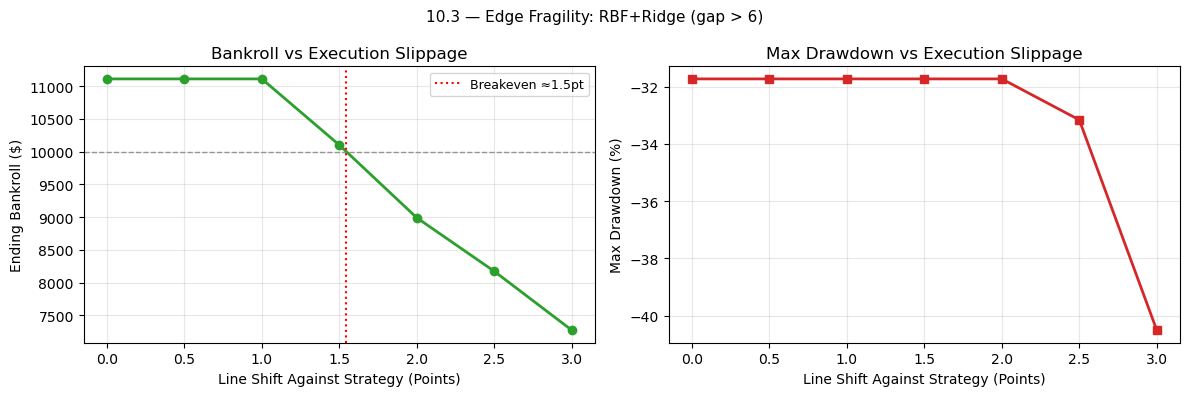

In [23]:
# ======================================================================
# 10.3 — Edge Fragility: Line Movement / Slippage Sensitivity
# ======================================================================

print("\n" + "=" * 70)
print("10.3 — EDGE FRAGILITY (Line Movement / Slippage Sensitivity)")
print("=" * 70)


def simulate_line_shift(dates, pred, actual, vegas, threshold, shift_pts,
                        start_bankroll=START_BANK):
    bet_over = pred > vegas
    execution_vegas = np.where(bet_over, vegas + shift_pts, vegas - shift_pts)
    _, summary = simulate_kelly(dates, pred, actual, vegas,
                                threshold=threshold,
                                start_bankroll=start_bankroll,
                                execution_vegas=execution_vegas)
    return summary


line_shifts = [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]

slip_results = {}
for shift in line_shifts:
    slip_results[shift] = simulate_line_shift(dates, p8_rbf_pred, actual, vegas,
                                              THRESHOLD, shift)

print(f"\nLine shift against strategy (execution line moved against us):")
print(f"{'Shift':>8}  {'Bankroll':>12}  {'Return':>10}  "
      f"{'Max DD':>10}  {'Underwater':>12}  {'Bets':>6}")
print("─" * 70)
for shift in line_shifts:
    s = slip_results[shift]
    print(f"  {shift:>+5.1f}pt  ${s['ending_bankroll']:>10,.0f}  "
          f"{s['bankroll_return_pct']:>+9.1f}%  "
          f"{s['max_drawdown_pct']:>9.1f}%  "
          f"{s['underwater_pct']:>10.0f}%  "
          f"{s['n_bets']:>5d}")

# Find breakeven slippage
breakeven_shift = None
for i in range(1, len(line_shifts)):
    prev = slip_results[line_shifts[i-1]]['bankroll_return_pct']
    curr = slip_results[line_shifts[i]]['bankroll_return_pct']
    if prev > 0 and curr <= 0:
        frac = prev / (prev - curr)
        breakeven_shift = line_shifts[i-1] + frac * (line_shifts[i] - line_shifts[i-1])
        break

if breakeven_shift is not None:
    print(f"\n  → Edge breaks even at ≈{breakeven_shift:.1f} points of slippage")
    print(f"    (typical retail NBA totals line movement: 0.5–1.5 points)")
else:
    first_neg = [s for s in line_shifts if slip_results[s]['bankroll_return_pct'] <= 0]
    if first_neg:
        print(f"\n  → Edge turns negative at {first_neg[0]:.1f} points of slippage")
    else:
        print(f"\n  → Edge survives all tested slippage levels")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
vals = [slip_results[s]['ending_bankroll'] for s in line_shifts]
ax.plot(line_shifts, vals, 'o-', color='#2ca02c', linewidth=2)
ax.axhline(START_BANK, color='gray', ls='--', lw=1, alpha=0.8)
if breakeven_shift:
    ax.axvline(breakeven_shift, color='red', ls=':', lw=1.5,
               label=f'Breakeven ≈{breakeven_shift:.1f}pt')
ax.set_xlabel('Line Shift Against Strategy (Points)')
ax.set_ylabel('Ending Bankroll ($)')
ax.set_title('Bankroll vs Execution Slippage')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
dd_vals = [slip_results[s]['max_drawdown_pct'] for s in line_shifts]
ax.plot(line_shifts, dd_vals, 's-', color='#d62728', linewidth=2)
ax.set_xlabel('Line Shift Against Strategy (Points)')
ax.set_ylabel('Max Drawdown (%)')
ax.set_title('Max Drawdown vs Execution Slippage')
ax.grid(True, alpha=0.3)

fig.suptitle('10.3 — Edge Fragility: RBF+Ridge (gap > 6)', fontsize=11)
fig.tight_layout(); plt.show()

## 10.4 Market Depth

Market depth and scalability. Retail sportsbooks, such as DraftKings, typically cap NBA totals bets at $5,000 to $10,000 per game.¹ If we assume there are 10 major sportsbooks offering this exact same cap, the absolute maximum capital that can safely be deployed across the market on a single game is $50,000 to $100,000. This functional ceiling dictates the strategy's maximum viable size. If we assume a strict bankroll management approach where our maximum bet size is capped at 10% of our total bankroll (a very aggressive maximum Kelly fraction), our total allowable bankroll is restricted to just $500,000 to $1,000,000.

Attempting to scale the bankroll higher and deploy larger amounts introduces a potential barrier that may arise even before market impact: sportsbooks might simply refuse the action. Because retail books operate as private entities that control their own platforms, they actively monitor users for winning behavior. Rather than adjusting the market line to absorb large bets, which could cause the 1 to 2 points of slippage that ruins our edge, sportsbooks often opt to restrict the profitable bettor instead. Even if our capital is small enough not to move the broader market, consistently beating the closing line means the books could flag the account, potentially slashing betting limits or banning us entirely. Furthermore, attempting to circumvent these restrictions by distributing bets across multiple accounts may not solve the issue; sportsbooks utilize profiling to track correlated betting patterns, meaning associated accounts executing the same strategy could also be linked and restricted.²

---
(1): Bleacher Nation. (2025, October 17). *What is the maximum bet I can place with online sportsbooks like DraftKings and FanDuel?* https://www.bleachernation.com/betting/2025/10/17/maximum-bet-size/

(2): Outlier. (2025, April 10). *Why sportsbooks limit your bets (and how to avoid it)*. https://outlier.bet/sports-betting-strategy/positive-ev-betting/why-sportsbooks-limit-your-bets/

## 10.5 Conclusion

While the RBF + Ridge strategy showed a profit in backtesting, it is unviable for a scaled real-world portfolio. First, the positive returns over just 30 bets are statistically insignificant and carry severe drawdown risk.

More importantly, the strategy cannot be scaled. Deploying meaningful capital into the relatively thin NBA totals market would likely move the line against us, creating the 1 to 2 points of slippage that instantly destroys our edge. Furthermore, even if the market absorbs the capital, retail sportsbooks actively profile and restrict profitable bettors. Any consistently successful account, or group of correlated accounts, would quickly be capped or banned.

Ultimately, while our model found a narrow theoretical edge, the practical realities of market depth, slippage, and strict sportsbook constraints make it impossible to monetize at scale.

## 